# Gaussian-Process Tuning of MPC Cost Weights from Recorded ROS2 Bags

This notebook optimizes MPC cost weights from recorded bag data using a Gaussian-process Bayesian optimization loop.

What it logs clearly:
- which bag is loaded
- how many messages and replay frames are extracted
- baseline score before optimization
- every random and GP-guided candidate
- the best-so-far objective
- the final parameter set written to disk

The goal is to minimize a replay-based objective built from tracking error, obstacle clearance, control effort, and smoothness.

In [1]:
# If needed in a fresh environment:
!pip install 'numpy<2.0' scipy scikit-learn pandas matplotlib


In [2]:
!pip install casadi

In [3]:
import os, sys, json, math, sqlite3, random, time
from dataclasses import replace
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message

try:
    from sensor_msgs_py import point_cloud2
except Exception:
    point_cloud2 = None

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm

REPO_ROOT = Path('/media/lorenzo/writable/Go2_navigation')
PKG_ROOT = REPO_ROOT / 'src' / 'a_star_mpc_planner'
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from a_star_mpc_planner.mpc_tracker import MPCConfig, MPCTracker


def log_section(title):
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")


def log_step(msg):
    print(f"[GP-TUNE] {msg}")


def fmt_dict(d, keys):
    return ', '.join(f"{k}={d[k]}" for k in keys if k in d)

In [ ]:
BAG_DB3 = REPO_ROOT / 'bags_recordings' / '20260429_140328' / 'bag' / 'bag_0.db3'
PARAM_YAML = REPO_ROOT / 'src' / 'a_star_mpc_planner' / 'config' / 'planner_params.yaml'

TOPIC_POSE = '/go2/pose'
TOPIC_PATH = '/a_star/path'
TOPIC_LIDAR = '/lidar/points_filtered'

MAX_FRAMES = 180
LIDAR_STRIDE = 12
LIDAR_MAX_POINTS = 300

N_INIT = 20
N_BO_ITERS = 100
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

assert BAG_DB3.exists(), BAG_DB3
assert PARAM_YAML.exists(), PARAM_YAML

log_section('Notebook setup')
log_step(f'Repository root: {REPO_ROOT}')
log_step(f'Bag file       : {BAG_DB3}')
log_step(f'Planner config : {PARAM_YAML}')
log_step(f'Random seed    : {RANDOM_SEED}')
log_step(f'Frames limit   : {MAX_FRAMES} (lidar stride={LIDAR_STRIDE}, max points={LIDAR_MAX_POINTS})')
log_step(f'BayesOpt rounds: {N_INIT} random + {N_BO_ITERS} GP-guided iterations')


Notebook setup
[GP-TUNE] Repository root: /media/lorenzo/writable/Go2_navigation
[GP-TUNE] Bag file       : /media/lorenzo/writable/Go2_navigation/bags_recordings/20260429_140328/bag/bag_0.db3
[GP-TUNE] Planner config : /media/lorenzo/writable/Go2_navigation/src/a_star_mpc_planner/config/planner_params.yaml
[GP-TUNE] Random seed    : 7
[GP-TUNE] Frames limit   : 180 (lidar stride=12, max points=300)
[GP-TUNE] BayesOpt rounds: 20 random + 100 GP-guided iterations


In [5]:
def yaw_from_quat(q):
    siny = 2.0 * (q.w * q.z + q.x * q.y)
    cosy = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return math.atan2(siny, cosy)


def wrap_pi(a):
    return math.atan2(math.sin(a), math.cos(a))


def load_topic_messages(db3_path, topic_name):
    con = sqlite3.connect(str(db3_path))
    cur = con.cursor()
    row = cur.execute('SELECT id, type FROM topics WHERE name=?', (topic_name,)).fetchone()
    if row is None:
        con.close()
        return []
    topic_id, type_name = row
    msg_type = get_message(type_name)
    rows = cur.execute('SELECT timestamp, data FROM messages WHERE topic_id=? ORDER BY timestamp ASC', (topic_id,)).fetchall()
    con.close()
    out = []
    for ts, raw in rows:
        out.append((ts * 1e-9, deserialize_message(raw, msg_type)))
    return out


def pointcloud2_to_xy(msg, stride=10, max_points=300):
    if point_cloud2 is not None:
        pts = []
        for i, p in enumerate(point_cloud2.read_points(msg, field_names=('x','y','z'), skip_nans=True)):
            if i % stride != 0:
                continue
            pts.append((float(p[0]), float(p[1])))
            if len(pts) >= max_points:
                break
        return np.asarray(pts, dtype=np.float64) if pts else np.empty((0,2), dtype=np.float64)

    fields = {f.name: (f.offset, f.datatype) for f in msg.fields}
    if 'x' not in fields or 'y' not in fields:
        return np.empty((0,2), dtype=np.float64)
    ox, _ = fields['x']
    oy, _ = fields['y']
    step = msg.point_step
    n = msg.width * msg.height
    buf = memoryview(msg.data)
    pts = []
    for i in range(0, n, stride):
        base = i * step
        x = np.frombuffer(buf[base+ox:base+ox+4], dtype=np.float32, count=1)[0]
        y = np.frombuffer(buf[base+oy:base+oy+4], dtype=np.float32, count=1)[0]
        if np.isfinite(x) and np.isfinite(y):
            pts.append((float(x), float(y)))
        if len(pts) >= max_points:
            break
    return np.asarray(pts, dtype=np.float64) if pts else np.empty((0,2), dtype=np.float64)


In [6]:
log_section('Load recorded bag messages')
log_step(f'Reading topics: {TOPIC_POSE}, {TOPIC_PATH}, {TOPIC_LIDAR}')
poses = load_topic_messages(BAG_DB3, TOPIC_POSE)
paths = load_topic_messages(BAG_DB3, TOPIC_PATH)
lidars = load_topic_messages(BAG_DB3, TOPIC_LIDAR)

log_step(f'Loaded poses  : {len(poses)} messages')
log_step(f'Loaded paths  : {len(paths)} messages')
log_step(f'Loaded lidars : {len(lidars)} messages')

assert len(poses) > 10 and len(paths) > 0 and len(lidars) > 0
log_step('Bag contents look valid for replay construction')


Load recorded bag messages
[GP-TUNE] Reading topics: /go2/pose, /a_star/path, /lidar/points_filtered
[GP-TUNE] Loaded poses  : 2574 messages
[GP-TUNE] Loaded paths  : 130 messages
[GP-TUNE] Loaded lidars : 1163 messages
[GP-TUNE] Bag contents look valid for replay construction


In [7]:
log_section('Build replay frames from synchronized bag signals')

def build_replay_frames(poses, paths, lidars, max_frames=200, lidar_stride=12, lidar_max_points=300):
    frames = []
    p_idx = 0
    l_idx = 0
    latest_path = None
    latest_lidar = None
    lidar_cache = {}

    log_step(f'Constructing aligned samples with max_frames={max_frames}')

    for i in range(1, len(poses)-1):
        t_prev, m_prev = poses[i-1]
        t_cur, m_cur = poses[i]
        t_next, m_next = poses[i+1]

        while p_idx < len(paths) and paths[p_idx][0] <= t_cur:
            latest_path = paths[p_idx][1]
            p_idx += 1
        while l_idx < len(lidars) and lidars[l_idx][0] <= t_cur:
            latest_lidar = lidars[l_idx][1]
            l_idx += 1

        if latest_path is None or latest_lidar is None:
            continue

        dt = t_cur - t_prev
        if dt <= 1e-3 or dt > 0.5:
            continue

        x_prev, y_prev = float(m_prev.pose.position.x), float(m_prev.pose.position.y)
        x_cur, y_cur = float(m_cur.pose.position.x), float(m_cur.pose.position.y)
        x_next, y_next = float(m_next.pose.position.x), float(m_next.pose.position.y)

        yaw_prev = yaw_from_quat(m_prev.pose.orientation)
        yaw_cur = yaw_from_quat(m_cur.pose.orientation)
        yaw_next = yaw_from_quat(m_next.pose.orientation)

        vx = (x_cur - x_prev) / dt
        vy = (y_cur - y_prev) / dt
        wz = wrap_pi(yaw_cur - yaw_prev) / dt

        path_xyz = [(float(ps.pose.position.x), float(ps.pose.position.y), float(ps.pose.position.z)) for ps in latest_path.poses]
        if len(path_xyz) < 2:
            continue

        lid_id = id(latest_lidar)
        if lid_id not in lidar_cache:
            lidar_cache[lid_id] = pointcloud2_to_xy(latest_lidar, stride=lidar_stride, max_points=lidar_max_points)
        obs_xy = lidar_cache[lid_id]

        frames.append({
            't': t_cur,
            'state': np.array([x_cur, y_cur, yaw_cur, vx, vy, wz], dtype=np.float64),
            'next_state': np.array([x_next, y_next, yaw_next], dtype=np.float64),
            'path': path_xyz,
            'obs_xy': obs_xy,
        })

    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames)-1, max_frames).astype(int)
        frames = [frames[k] for k in idx]

    return frames

frames = build_replay_frames(poses, paths, lidars, MAX_FRAMES, LIDAR_STRIDE, LIDAR_MAX_POINTS)
log_step(f'Replay frames constructed: {len(frames)}')
assert len(frames) >= 30
log_step('Replay set is large enough for GP optimization')


Build replay frames from synchronized bag signals
[GP-TUNE] Constructing aligned samples with max_frames=180
[GP-TUNE] Replay frames constructed: 180
[GP-TUNE] Replay set is large enough for GP optimization


In [8]:
import yaml
with open(PARAM_YAML, 'r') as f:
    base_yaml = yaml.safe_load(f)
ros_params = base_yaml['/**']['ros__parameters']

base_cfg = MPCConfig(
    N=int(ros_params['mpc_N']),
    dt=float(ros_params['mpc_dt']),
    tau_v=float(ros_params['mpc_tau_v']),
    tau_w=float(ros_params['mpc_tau_w']),
    vx_max=float(ros_params['mpc_vx_max']),
    vy_max=float(ros_params['mpc_vy_max']),
    omega_max=float(ros_params['mpc_omega_max']),
    v_ref=float(ros_params['mpc_v_ref']),
    Q_x=float(ros_params['mpc_Q_x']),
    Q_y=float(ros_params['mpc_Q_y']),
    Q_yaw=float(ros_params['mpc_Q_yaw']),
    Q_terminal=float(ros_params['mpc_Q_terminal']),
    R_vx=float(ros_params['mpc_R_vx']),
    R_vy=float(ros_params['mpc_R_vy']),
    R_omega=float(ros_params['mpc_R_omega']),
    R_jerk=float(ros_params['mpc_R_jerk']),
    W_obs_sigmoid=float(ros_params['mpc_W_obs_sigmoid']),
    obs_alpha=float(ros_params['mpc_obs_alpha']),
    obs_r=float(ros_params['mpc_obs_r']),
    max_obs_constraints=int(ros_params['mpc_max_obs_constraints']),
    obs_check_radius=float(ros_params['mpc_obs_check_radius']),
    max_iter=int(ros_params['mpc_max_iter']),
    warm_start=bool(ros_params['mpc_warm_start']),
)
base_cfg


MPCConfig(N=50, dt=0.1, tau_v=0.12, tau_w=0.1, vx_max=1.0, vy_max=0.5, omega_max=1.5, v_ref=0.5, Q_x=300.0, Q_y=300.0, Q_yaw=10.0, Q_terminal=100.0, R_vx=0.5, R_vy=0.5, R_omega=0.5, R_jerk=1.0, W_obs_sigmoid=200.0, obs_alpha=4.0, obs_r=0.45, max_obs_constraints=12, obs_check_radius=3.0, max_iter=100, warm_start=True, print_level=0)

In [9]:
PARAM_BOUNDS = {
    'Q_x': (50.0, 500.0),
    'Q_y': (50.0, 500.0),
    'Q_yaw': (0.05, 15.0),
    'Q_terminal': (20.0, 300.0),
    'R_vx': (0.1, 3.0),
    'R_vy': (0.1, 3.0),
    'R_omega': (0.1, 3.0),
    'R_jerk': (0.1, 5.0),
    'W_obs_sigmoid': (50.0, 400.0),
    'obs_alpha': (1.0, 8.0),
    'obs_r': (0.35, 0.85),
}
PARAM_NAMES = list(PARAM_BOUNDS.keys())
LOW = np.array([PARAM_BOUNDS[k][0] for k in PARAM_NAMES], dtype=np.float64)
HIGH = np.array([PARAM_BOUNDS[k][1] for k in PARAM_NAMES], dtype=np.float64)

log_section('MPC parameter search space')
for name in PARAM_NAMES:
    lo, hi = PARAM_BOUNDS[name]
    log_step(f'{name:14s}: [{lo:.4f}, {hi:.4f}]')


def vec_to_param_dict(xvec):
    return {k: float(v) for k, v in zip(PARAM_NAMES, xvec)}


def make_cfg_from_vec(base, xvec):
    p = vec_to_param_dict(xvec)
    return replace(base, Q_x=p['Q_x'], Q_y=p['Q_y'], Q_yaw=p['Q_yaw'], Q_terminal=p['Q_terminal'],
                   R_vx=p['R_vx'], R_vy=p['R_vy'], R_omega=p['R_omega'], R_jerk=p['R_jerk'],
                   W_obs_sigmoid=p['W_obs_sigmoid'], obs_alpha=p['obs_alpha'], obs_r=p['obs_r'])


def min_obstacle_distance(pt_xy, obs_xy):
    if obs_xy is None or len(obs_xy) == 0:
        return np.inf
    return float(np.min(np.linalg.norm(obs_xy - pt_xy[None, :], axis=1)))


def evaluate_params(xvec, frames, base_cfg):
    cfg = make_cfg_from_vec(base_cfg, xvec)
    tracker = MPCTracker(config=cfg)

    J = 0.0
    n_fail = 0
    prev_u0 = None

    for fr in frames:
        state = fr['state']
        gt_next = fr['next_state']
        path = fr['path']
        obs = fr['obs_xy']

        res = tracker.solve(state, path, obstacle_points_2d=obs)
        if (not res.success) or (res.x_pred is None) or (len(res.x_pred) < 2):
            J += 25.0
            n_fail += 1
            continue

        pred_next = res.x_pred[1]
        e_pos = float(np.linalg.norm(pred_next[:2] - gt_next[:2]))
        e_yaw = abs(wrap_pi(float(pred_next[2] - gt_next[2])))

        u0 = res.u_opt[0] if res.u_opt is not None and len(res.u_opt) > 0 else np.zeros(3)
        u_norm = float(np.linalg.norm(u0))
        jerk = float(np.linalg.norm(u0 - prev_u0)) if prev_u0 is not None else 0.0
        prev_u0 = u0.copy()

        dmin = min_obstacle_distance(pred_next[:2], obs)
        obs_violation = max(0.0, cfg.obs_r - dmin)

        step_loss = (
            8.0 * (e_pos ** 2) +
            2.0 * (e_yaw ** 2) +
            0.2 * (u_norm ** 2) +
            0.6 * (jerk ** 2) +
            30.0 * (obs_violation ** 2) +
            0.002 * float(res.solve_time_ms)
        )

        if (not np.isfinite(step_loss)) or step_loss > 1e6:
            J += 50.0
            n_fail += 1
            continue

        J += step_loss

    n_total = max(1, len(frames))
    fail_ratio = n_fail / n_total
    J = J / n_total + 20.0 * fail_ratio
    return float(J), {'fail_ratio': float(fail_ratio), 'fail_count': int(n_fail)}


MPC parameter search space
[GP-TUNE] Q_x           : [50.0000, 500.0000]
[GP-TUNE] Q_y           : [50.0000, 500.0000]
[GP-TUNE] Q_yaw         : [0.0500, 15.0000]
[GP-TUNE] Q_terminal    : [20.0000, 300.0000]
[GP-TUNE] R_vx          : [0.1000, 3.0000]
[GP-TUNE] R_vy          : [0.1000, 3.0000]
[GP-TUNE] R_omega       : [0.1000, 3.0000]
[GP-TUNE] R_jerk        : [0.1000, 5.0000]
[GP-TUNE] W_obs_sigmoid : [50.0000, 400.0000]
[GP-TUNE] obs_alpha     : [1.0000, 8.0000]
[GP-TUNE] obs_r         : [0.3500, 0.8500]


In [10]:
log_section('Baseline score before optimization')
x0 = np.array([getattr(base_cfg, k) for k in PARAM_NAMES], dtype=np.float64)
log_step('Evaluating the starting MPC weights from planner_params.yaml')
J0, info0 = evaluate_params(x0, frames, base_cfg)
log_step(f'Baseline objective = {J0:.6f}')
log_step(f'Baseline failures   = {info0["fail_count"]} / {len(frames)} ({info0["fail_ratio"]:.1%})')
log_step('This baseline becomes the reference point for GP search')


Baseline score before optimization
[GP-TUNE] Evaluating the starting MPC weights from planner_params.yaml
[GP-TUNE] Baseline objective = 1.823502
[GP-TUNE] Baseline failures   = 1 / 180 (0.6%)
[GP-TUNE] This baseline becomes the reference point for GP search


In [11]:
PARAM_BOUNDS = {
    'Q_x': (50.0, 200.0),
    'Q_y': (50.0, 200.0),
    'Q_yaw': (0.0, 15.0),
    'Q_terminal': (50.0, 300.0),
    'R_vx': (0.1, 10.0),
    'R_vy': (0.1, 10.0),
    'R_omega': (0.1, 10.0),
    'R_jerk': (0.1, 5.0),
    'W_obs_sigmoid': (1.0, 500.0),
    'obs_alpha': (0.1, 15.0),
    'obs_r': (0.05, 1.0),
}
PARAM_NAMES = list(PARAM_BOUNDS.keys())
LOW = np.array([PARAM_BOUNDS[k][0] for k in PARAM_NAMES])
HIGH = np.array([PARAM_BOUNDS[k][1] for k in PARAM_NAMES])

# For scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
scaler.fit(np.vstack([LOW, HIGH]));

In [12]:
def fit_gp(X_train, y_train):
    """Fits a Gaussian Process Regressor to the training data."""
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e2))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        alpha=1e-2,
        normalize_y=True,
        random_state=RANDOM_SEED
    )
    gp.fit(X_train, y_train)
    return gp


def propose_next(gp, scaler):
    """Proposes the next sample point by maximizing the Expected Improvement acquisition function."""
    # Generate a large number of random samples in the normalized [0,1] space
    n_probes = 5000
    probes = np.random.rand(n_probes, scaler.n_features_in_)
    
    # Predict mean and std dev for the probes
    mu, std = gp.predict(probes, return_std=True)
    
    # Get the best observed objective so far (minimum)
    y_best = np.min(gp.y_train_)
    
    # Calculate Expected Improvement (EI)
    with np.errstate(divide='ignore'): # Ignore division by zero for probes with zero std
        imp = y_best - mu
        Z = imp / std
        ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
        ei[std == 0.0] = 0.0

    # Find the probe that maximizes EI
    best_idx = np.argmax(ei)
    x_next_normalized = probes[best_idx]
    
    # Denormalize to get the actual parameter vector
    x_next = scaler.inverse_transform(x_next_normalized.reshape(1, -1)).flatten()
    
    # Return the next point and some diagnostics
    max_ei = float(ei[best_idx])
    pred_mu = float(mu[best_idx])
    pred_std = float(std[best_idx])
    
    return x_next, max_ei, pred_mu, pred_std


In [13]:
log_section('Gaussian-process Bayesian optimization')
history = []
X = []
y = []

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.vstack([LOW, HIGH]))

log_step(f'Random initialization: {N_INIT} samples')
for i in range(N_INIT):
    x = LOW + np.random.rand(len(PARAM_NAMES)) * (HIGH - LOW)
    obj, info = evaluate_params(x, frames, base_cfg)
    X.append(x)
    y.append(obj)
    history.append({'iter': i, 'mode': 'random', 'objective': obj, **vec_to_param_dict(x), **info})
    log_step(f'[{i:02d}] random  obj={obj:.4f}  fail={info["fail_ratio"]:.1%}  params={fmt_dict(vec_to_param_dict(x), PARAM_NAMES[:4])}')

log_step(f'GP-guided search: {N_BO_ITERS} iterations')
for k in range(N_BO_ITERS):
    X_arr = np.asarray(X, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    Xn = scaler.transform(X_arr)

    gp = fit_gp(Xn, y_arr)
    x_next, ei, mu, std = propose_next(gp, scaler)
    obj, info = evaluate_params(x_next, frames, base_cfg)

    X.append(x_next)
    y.append(obj)
    history.append({'iter': N_INIT+k, 'mode': 'gp', 'objective': obj, 'ei': ei, 'mu': mu, 'std': std,
                    **vec_to_param_dict(x_next), **info})
    log_step(
        f'[{N_INIT+k:02d}] gp      obj={obj:.4f}  ei={ei:.4f}  '
        f'mu={mu:.4f}  std={std:.4f}  fail={info["fail_ratio"]:.1%}'
    )
    log_step('        ' + fmt_dict(vec_to_param_dict(x_next), PARAM_NAMES))

hist_df = pd.DataFrame(history)
log_step(f'Optimization complete: best objective so far = {hist_df["objective"].min():.6f}')
hist_df.sort_values('objective').head(10)


Gaussian-process Bayesian optimization
[GP-TUNE] Random initialization: 20 samples
[GP-TUNE] [00] random  obj=2.1929  fail=0.6%  params=Q_x=61.44624340609357, Q_y=166.9878188360172, Q_yaw=6.576138471613403, Q_terminal=230.8662944577353
[GP-TUNE] [01] random  obj=4.0033  fail=1.1%  params=Q_x=170.5608554156563, Q_y=107.14116997228075, Q_yaw=0.9890452035885766, Q_terminal=122.03639982699839
[GP-TUNE] [02] random  obj=1.0585  fail=0.0%  params=Q_x=84.54543185314472, Q_y=132.27348788540456, Q_yaw=13.63692562330097, Q_terminal=83.29236143981254
[GP-TUNE] [03] random  obj=1.4240  fail=0.6%  params=Q_x=121.61017322773826, Q_y=104.88355786708894, Q_yaw=12.56876991463891, Q_terminal=242.16187662987733
[GP-TUNE] [04] random  obj=1.5158  fail=0.6%  params=Q_x=118.86394668371472, Q_y=157.89861837635624, Q_yaw=6.194877436707519, Q_terminal=276.6058172910847
[GP-TUNE] [05] random  obj=0.9307  fail=0.0%  params=Q_x=50.21403208441373, Q_y=63.83935187701281, Q_yaw=10.640915905878192, Q_terminal=181.08

/media/lorenzo/writable/Go2_diffusion/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GP-TUNE] [21] gp      obj=0.6517  ei=0.0013  mu=0.9953  std=0.7967  fail=0.0%
[GP-TUNE]         Q_x=78.548952882972, Q_y=62.32249780091016, Q_yaw=5.665821412085722, Q_terminal=119.09545885539156, R_vx=3.3181203300703843, R_vy=8.235087094141893, R_omega=5.992629770439276, R_jerk=1.9093934852334093, W_obs_sigmoid=60.530198164090585, obs_alpha=14.78436958882165, obs_r=0.06291109396969582


/media/lorenzo/writable/Go2_diffusion/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GP-TUNE] [22] gp      obj=0.7195  ei=0.0008  mu=1.1899  std=0.8673  fail=0.0%
[GP-TUNE]         Q_x=53.62824366216232, Q_y=93.36881725341364, Q_yaw=0.7994824672956102, Q_terminal=241.63805341080896, R_vx=5.175939747812652, R_vy=8.223541674955547, R_omega=9.948483433436548, R_jerk=4.804904659953233, W_obs_sigmoid=447.4538598938796, obs_alpha=6.905573769127782, obs_r=0.050530427887978846


...

/media/lorenzo/writable/Go2_diffusion/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GP-TUNE] [25] gp      obj=0.5884  ei=0.0009  mu=1.1122  std=0.8220  fail=0.0%
[GP-TUNE]         Q_x=50.052667587025184, Q_y=181.21584919168922, Q_yaw=1.6362276713216384, Q_terminal=157.42856466852228, R_vx=2.0561873088662477, R_vy=1.728902703930628, R_omega=3.51630769983977, R_jerk=4.855230849882142, W_obs_sigmoid=10.187366087827362, obs_alpha=12.724359508104824, obs_r=0.1005927064268069


/media/lorenzo/writable/Go2_diffusion/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GP-TUNE] [26] gp      obj=1.0359  ei=0.0012  mu=0.9356  std=0.7727  fail=0.0%
[GP-TUNE]         Q_x=75.26877612582803, Q_y=197.67995013757437, Q_yaw=11.960688352333674, Q_terminal=229.05381371686346, R_vx=0.3485923054485837, R_vy=8.590557583071266, R_omega=1.3562479980977007, R_jerk=4.902760186867983, W_obs_sigmoid=423.4091753272453, obs_alpha=12.238569810355719, obs_r=0.0678494057749048
[GP-TUNE] [27] gp      obj=0.5959  ei=0.0013  mu=0.8525  std=0.7465  fail=0.0%
[GP-TUNE]         Q_x=57.83769695098778, Q_y=56.590746435046015, Q_yaw=3.9505988738577176, Q_terminal=289.8497049317291, R_vx=8.529883349114812, R_vy=0.18402775119389694, R_omega=7.009518355649175, R_jerk=0.994184711957936, W_obs_sigmoid=141.85793307572348, obs_alpha=13.853056575743901, obs_r=0.053597058243994924
[GP-TUNE] [28] gp      obj=0.7429  ei=0.0010  mu=0.8689  std=0.7155  fail=0.0%
[GP-TUNE]         Q_x=89.76355653847929, Q_y=108.70007118701238, Q_yaw=1.505911400719735, Q_terminal=298.1639179686797, R_vx=2.54252321

,iter,mode,objective,Q_x,Q_y,Q_yaw,Q_terminal,R_vx,R_vy,R_omega,R_jerk,W_obs_sigmoid,obs_alpha,obs_r,fail_ratio,fail_count,ei,mu,std
85,85,gp,0.457993,60.450352,166.938813,0.281195,141.882313,9.488405,8.631337,8.651403,1.139896,15.319213,14.887882,0.054357,0.0,0,4.655981e-07,0.486726,0.295700
64,64,gp,0.483594,65.302649,158.204974,1.931942,186.630264,7.940487,9.486068,9.831713,4.509991,99.216769,14.842455,0.073600,0.0,0,1.513520e-05,0.469752,0.344324
88,88,gp,0.484058,83.728518,58.315717,0.414634,298.660884,3.987054,4.616147,9.771589,1.675527,1.207514,10.503023,0.072805,0.0,0,1.007674e-08,0.586047,0.278672
115,115,gp,0.487533,53.952148,122.116860,0.414775,293.893357,9.510485,8.073409,9.077406,4.517750,280.955577,14.731049,0.113018,0.0,0,7.472138e-10,0.519661,0.238103
97,97,gp,0.488680,72.842007,59.713825,0.092311,123.093258,8.222951,9.761107,8.947614,1.395314,93.219111,8.382985,0.051574,0.0,0,2.547212e-09,0.541080,0.254487
108,108,gp,0.499062,56.918176,129.748438,0.181902,253.076084,8.985113,2.767975,8.767695,4.396546,13.448562,12.435835,0.092801,0.0,0,1.768759e-08,0.489436,0.262434
84,84,gp,0.517244,102.657656,96.129041,2.121769,125.204683,9.193978,9.786487,8.881739,1.145421,3.640470,13.251336,0.052398,0.0,0,2.937347e-07,0.532377,0.300858
103,103,gp,0.522916,57.444255,186.942468,0.294817,281.172208,8.390132,8.109707,9.161695,1.220251,335.335834,13.410569,0.089503,0.0,0,4.911891e-09,0.548922,0.261616
109,109,gp,0.523404,60.159876,153.974020,0.965773,191.611925,7.924408,5.677055,8.572506,4.351468,258.532109,14.307426,0.082997,0.0,0,1.104401e-09,0.483485,0.237148
39,39,gp,0.525546,154.835086,56.133266,0.276484,225.248225,8.376723,9.510857,9.751225,3.804218,239.465987,13.076682,0.070000,0.0,0,9.858399e-05,0.915223,0.547634



Best parameter set and objective trace
[GP-TUNE] Best objective found = 0.457993
[GP-TUNE] Best parameters:
[GP-TUNE]   Q_x           : 60.450352
[GP-TUNE]   Q_y           : 166.938813
[GP-TUNE]   Q_yaw         : 0.281195
[GP-TUNE]   Q_terminal    : 141.882313
[GP-TUNE]   R_vx          : 9.488405
[GP-TUNE]   R_vy          : 8.631337
[GP-TUNE]   R_omega       : 8.651403
[GP-TUNE]   R_jerk        : 1.139896
[GP-TUNE]   W_obs_sigmoid : 15.319213
[GP-TUNE]   obs_alpha     : 14.887882
[GP-TUNE]   obs_r         : 0.054357


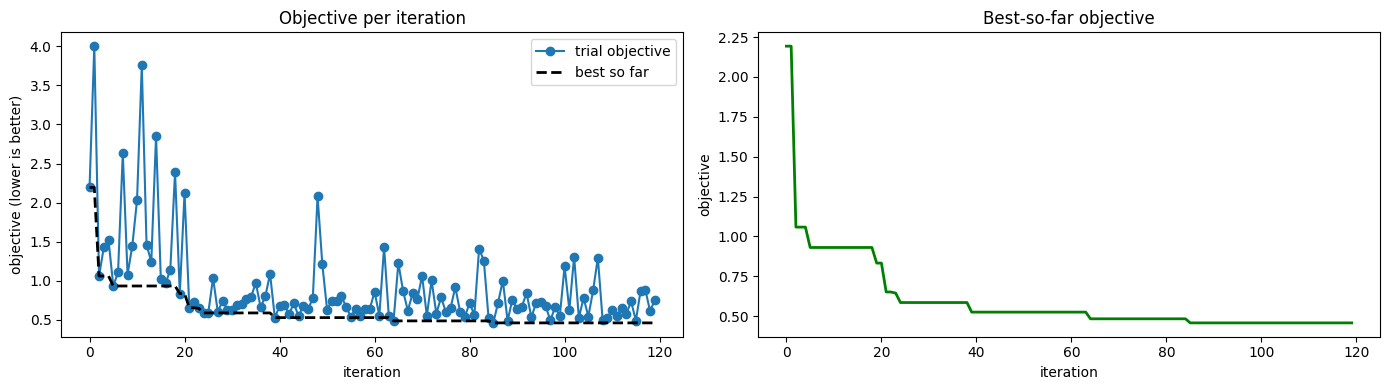

[GP-TUNE] Use the saved JSON/YAML-ready summary cell below to copy parameters into planner_params.yaml


In [14]:
log_section('Best parameter set and objective trace')
best_idx = int(np.argmin(np.asarray(y)))
best_x = np.asarray(X)[best_idx]
best_obj = float(np.min(np.asarray(y)))
best_params = vec_to_param_dict(best_x)

log_step(f'Best objective found = {best_obj:.6f}')
log_step('Best parameters:')
for k in PARAM_NAMES:
    log_step(f'  {k:14s}: {best_params[k]:.6f}')

plot_df = hist_df.copy()
plot_df['best_so_far'] = plot_df['objective'].cummin()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(plot_df['iter'], plot_df['objective'], 'o-', label='trial objective')
ax[0].plot(plot_df['iter'], plot_df['best_so_far'], 'k--', lw=2, label='best so far')
ax[0].set_title('Objective per iteration')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('objective (lower is better)')
ax[0].legend()

ax[1].plot(plot_df['iter'], plot_df['best_so_far'], 'g-', lw=2)
ax[1].set_title('Best-so-far objective')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('objective')
plt.tight_layout()
plt.show()

log_step('Use the saved JSON/YAML-ready summary cell below to copy parameters into planner_params.yaml')

In [15]:
log_section('Save optimization results')
out_dir = REPO_ROOT / 'bag_gp_tuning'
out_dir.mkdir(parents=True, exist_ok=True)

record = {
    'bag': str(BAG_DB3),
    'frames_used': len(frames),
    'n_init': N_INIT,
    'n_bo_iters': N_BO_ITERS,
    'best_objective': best_obj,
    'best_params': best_params,
    'history': history,
}
with open(out_dir / 'gp_bag_tuning_history.json', 'w') as f:
    json.dump(record, f, indent=2)

key_map = {
    'Q_x': 'mpc_Q_x',
    'Q_y': 'mpc_Q_y',
    'Q_yaw': 'mpc_Q_yaw',
    'Q_terminal': 'mpc_Q_terminal',
    'R_vx': 'mpc_R_vx',
    'R_vy': 'mpc_R_vy',
    'R_omega': 'mpc_R_omega',
    'R_jerk': 'mpc_R_jerk',
    'W_obs_sigmoid': 'mpc_W_obs_sigmoid',
    'obs_alpha': 'mpc_obs_alpha',
    'obs_r': 'mpc_obs_r',
}

log_step(f'Saved history to: {out_dir / "gp_bag_tuning_history.json"}')
log_step('Copy the following into planner_params.yaml:')
for k in PARAM_NAMES:
    log_step(f'  {key_map[k]}: {best_params[k]:.6f}')


Save optimization results
[GP-TUNE] Saved history to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_bag_tuning_history.json
[GP-TUNE] Copy the following into planner_params.yaml:
[GP-TUNE]   mpc_Q_x: 60.450352
[GP-TUNE]   mpc_Q_y: 166.938813
[GP-TUNE]   mpc_Q_yaw: 0.281195
[GP-TUNE]   mpc_Q_terminal: 141.882313
[GP-TUNE]   mpc_R_vx: 9.488405
[GP-TUNE]   mpc_R_vy: 8.631337
[GP-TUNE]   mpc_R_omega: 8.651403
[GP-TUNE]   mpc_R_jerk: 1.139896
[GP-TUNE]   mpc_W_obs_sigmoid: 15.319213
[GP-TUNE]   mpc_obs_alpha: 14.887882
[GP-TUNE]   mpc_obs_r: 0.054357


In [16]:
# Post-optimization MPC cost-function plots
log_section('Post-optimization MPC cost-function plots')

def evaluate_params_detailed(xvec, frames, base_cfg):
    cfg = make_cfg_from_vec(base_cfg, xvec)
    tracker = MPCTracker(config=cfg)

    terms = {
        'tracking_xy': [],
        'tracking_yaw': [],
        'control_effort': [],
        'control_jerk': [],
        'obstacle': [],
        'solver_time': [],
        'penalty_fail': [],
        'step_total': [],
    }

    n_fail = 0
    prev_u0 = None

    for fr in frames:
        state = fr['state']
        gt_next = fr['next_state']
        path = fr['path']
        obs = fr['obs_xy']

        res = tracker.solve(state, path, obstacle_points_2d=obs)
        if (not res.success) or (res.x_pred is None) or (len(res.x_pred) < 2):
            fail_pen = 25.0
            terms['tracking_xy'].append(0.0)
            terms['tracking_yaw'].append(0.0)
            terms['control_effort'].append(0.0)
            terms['control_jerk'].append(0.0)
            terms['obstacle'].append(0.0)
            terms['solver_time'].append(0.0)
            terms['penalty_fail'].append(fail_pen)
            terms['step_total'].append(fail_pen)
            n_fail += 1
            continue

        pred_next = res.x_pred[1]
        e_pos = float(np.linalg.norm(pred_next[:2] - gt_next[:2]))
        e_yaw = abs(wrap_pi(float(pred_next[2] - gt_next[2])))

        u0 = res.u_opt[0] if res.u_opt is not None and len(res.u_opt) > 0 else np.zeros(3)
        u_norm = float(np.linalg.norm(u0))
        jerk = float(np.linalg.norm(u0 - prev_u0)) if prev_u0 is not None else 0.0
        prev_u0 = u0.copy()

        dmin = min_obstacle_distance(pred_next[:2], obs)
        obs_violation = max(0.0, cfg.obs_r - dmin)

        c_xy = 8.0 * (e_pos ** 2)
        c_yaw = 2.0 * (e_yaw ** 2)
        c_u = 0.2 * (u_norm ** 2)
        c_j = 0.6 * (jerk ** 2)
        c_obs = 30.0 * (obs_violation ** 2)
        c_t = 0.002 * float(res.solve_time_ms)

        step_loss = c_xy + c_yaw + c_u + c_j + c_obs + c_t

        if (not np.isfinite(step_loss)) or step_loss > 1e6:
            fail_pen = 50.0
            terms['tracking_xy'].append(0.0)
            terms['tracking_yaw'].append(0.0)
            terms['control_effort'].append(0.0)
            terms['control_jerk'].append(0.0)
            terms['obstacle'].append(0.0)
            terms['solver_time'].append(0.0)
            terms['penalty_fail'].append(fail_pen)
            terms['step_total'].append(fail_pen)
            n_fail += 1
            continue

        terms['tracking_xy'].append(c_xy)
        terms['tracking_yaw'].append(c_yaw)
        terms['control_effort'].append(c_u)
        terms['control_jerk'].append(c_j)
        terms['obstacle'].append(c_obs)
        terms['solver_time'].append(c_t)
        terms['penalty_fail'].append(0.0)
        terms['step_total'].append(step_loss)

    n_total = max(1, len(frames))
    fail_ratio = n_fail / n_total

    means = {k: float(np.mean(v)) for k, v in terms.items()}
    objective = means['step_total'] + means['penalty_fail'] + 20.0 * fail_ratio

    return {
        'objective': float(objective),
        'fail_ratio': float(fail_ratio),
        'means': means,
        'series': {k: np.asarray(v, dtype=np.float64) for k, v in terms.items()},
    }



Post-optimization MPC cost-function plots


In [17]:
base_det = evaluate_params_detailed(x0, frames, base_cfg)
best_det = evaluate_params_detailed(best_x, frames, base_cfg)

log_step(f"Baseline detailed objective : {base_det['objective']:.6f}")
log_step(f"Optimized detailed objective: {best_det['objective']:.6f}")
log_step(f"Baseline fail ratio         : {base_det['fail_ratio']:.2%}")
log_step(f"Optimized fail ratio        : {best_det['fail_ratio']:.2%}")


[GP-TUNE] Baseline detailed objective : 1.959734
[GP-TUNE] Optimized detailed objective: 0.457392
[GP-TUNE] Baseline fail ratio         : 0.56%
[GP-TUNE] Optimized fail ratio        : 0.00%


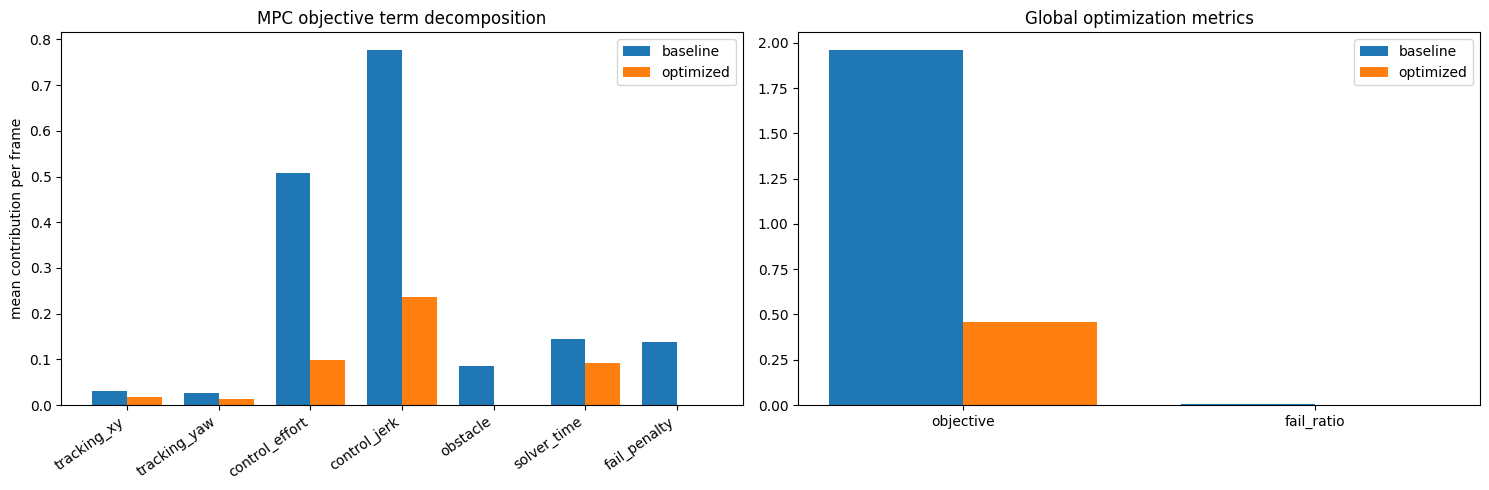

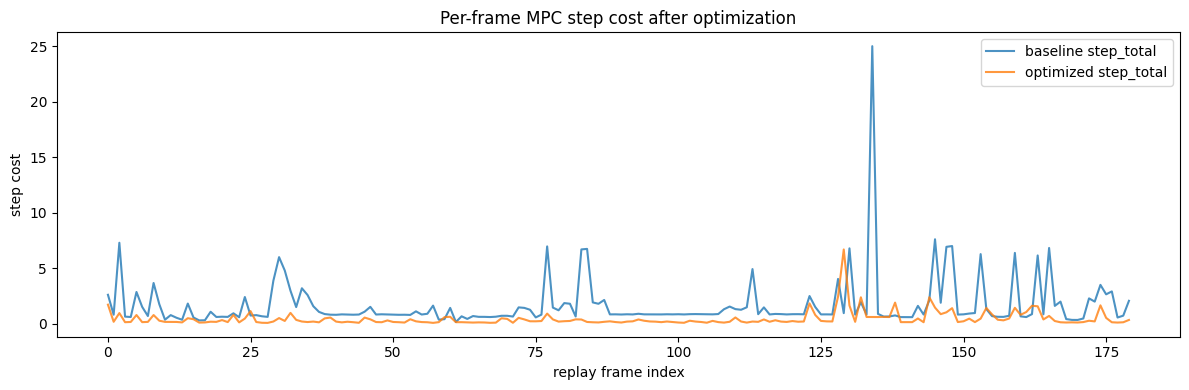

In [18]:
# 1) MPC cost-term decomposition (baseline vs optimized)
term_order = [
    'tracking_xy', 'tracking_yaw', 'control_effort',
    'control_jerk', 'obstacle', 'solver_time', 'penalty_fail'
]
term_labels = {
    'tracking_xy': 'tracking_xy',
    'tracking_yaw': 'tracking_yaw',
    'control_effort': 'control_effort',
    'control_jerk': 'control_jerk',
    'obstacle': 'obstacle',
    'solver_time': 'solver_time',
    'penalty_fail': 'fail_penalty',
}

base_vals = [base_det['means'][k] for k in term_order]
best_vals = [best_det['means'][k] for k in term_order]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(term_order))
w = 0.38
ax[0].bar(x - w/2, base_vals, width=w, label='baseline')
ax[0].bar(x + w/2, best_vals, width=w, label='optimized')
ax[0].set_xticks(x)
ax[0].set_xticklabels([term_labels[k] for k in term_order], rotation=35, ha='right')
ax[0].set_ylabel('mean contribution per frame')
ax[0].set_title('MPC objective term decomposition')
ax[0].legend()

# Objective + fail ratio summary
summary_names = ['objective', 'fail_ratio']
base_s = [base_det['objective'], base_det['fail_ratio']]
best_s = [best_det['objective'], best_det['fail_ratio']]
xs = np.arange(len(summary_names))
ax[1].bar(xs - w/2, base_s, width=w, label='baseline')
ax[1].bar(xs + w/2, best_s, width=w, label='optimized')
ax[1].set_xticks(xs)
ax[1].set_xticklabels(summary_names)
ax[1].set_title('Global optimization metrics')
ax[1].legend()

plt.tight_layout()
plt.show()

# 2) Frame-wise step cost evolution
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(base_det['series']['step_total'], label='baseline step_total', alpha=0.8)
ax.plot(best_det['series']['step_total'], label='optimized step_total', alpha=0.8)
ax.set_xlabel('replay frame index')
ax.set_ylabel('step cost')
ax.set_title('Per-frame MPC step cost after optimization')
ax.legend()
plt.tight_layout()
plt.show()


SystemError: <built-in function OptiSol_value> returned a result with an exception set

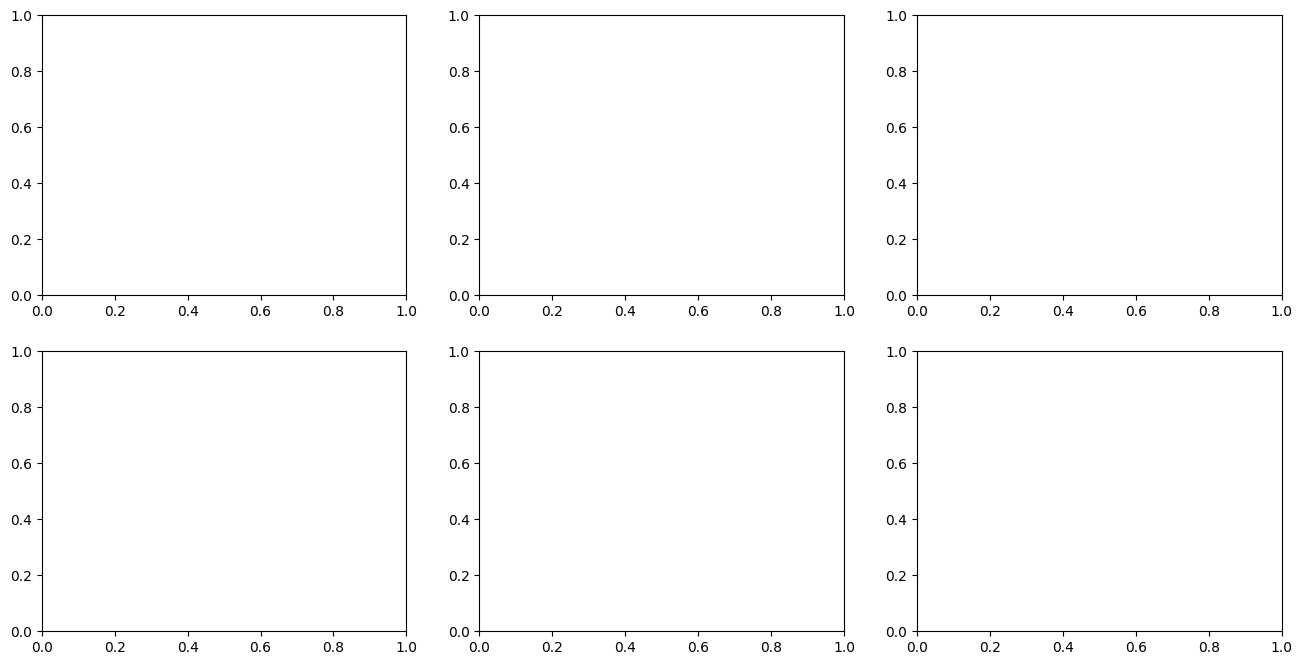

In [ ]:
# # 3) Local cost-function slices around optimized parameters

# slice_params = ['Q_x', 'Q_y', 'R_jerk', 'W_obs_sigmoid', 'obs_r']
# n_grid = 18

# fig, axes = plt.subplots(2, 3, figsize=(16, 8))
# axes = axes.flatten()

# for idx, pname in enumerate(slice_params):
#     ax = axes[idx]
#     lo, hi = PARAM_BOUNDS[pname]
#     xs = np.linspace(lo, hi, n_grid)
#     ys = []
#     pidx = PARAM_NAMES.index(pname)

#     for xv in xs:
#         xprobe = best_x.copy()
#         xprobe[pidx] = xv
#         obj, _ = evaluate_params(xprobe, frames, base_cfg)
#         ys.append(obj)

#     ys = np.asarray(ys)
#     ax.plot(xs, ys, '-o', ms=3)
#     ax.axvline(best_x[pidx], color='r', linestyle='--', label='best')
#     ax.set_title(f'Cost slice: {pname}')
#     ax.set_xlabel(pname)
#     ax.set_ylabel('objective')
#     ax.legend()

# # Optional 2D slice for interaction insight
# ax2 = axes[-1]
# p1, p2 = 'Q_x', 'W_obs_sigmoid'
# i1, i2 = PARAM_NAMES.index(p1), PARAM_NAMES.index(p2)
# x1 = np.linspace(*PARAM_BOUNDS[p1], 12)
# x2 = np.linspace(*PARAM_BOUNDS[p2], 12)
# Z = np.zeros((len(x1), len(x2)))
# for i, a in enumerate(x1):
#     for j, b in enumerate(x2):
#         xprobe = best_x.copy()
#         xprobe[i1] = a
#         xprobe[i2] = b
#         obj, _ = evaluate_params(xprobe, frames, base_cfg)
#         Z[i, j] = obj

# im = ax2.imshow(
#     Z.T, origin='lower', aspect='auto',
#     extent=[x1.min(), x1.max(), x2.min(), x2.max()]
# )
# ax2.scatter([best_x[i1]], [best_x[i2]], c='r', s=50, marker='x', label='best')
# ax2.set_xlabel(p1)
# ax2.set_ylabel(p2)
# ax2.set_title('2D local objective slice')
# ax2.legend(loc='best')
# fig.colorbar(im, ax=ax2, label='objective')

# for k in range(len(slice_params), len(axes)-1):
#     axes[k].axis('off')

# plt.tight_layout()
# plt.show()


# GP Surrogate and Trajectory Analysis

Visualize the Gaussian Process surrogate model and compare baseline vs optimized MPC trajectories.

In [20]:
log_section('Load saved GP training data')

# Load the optimization history from previous run
history_file = REPO_ROOT / 'bag_gp_tuning' / 'gp_bag_tuning_history.json'
assert history_file.exists(), f'History file not found: {history_file}'

with open(history_file, 'r') as f:
    saved_record = json.load(f)

saved_history = saved_record['history']
log_step(f'Loaded {len(saved_history)} optimization samples from {history_file}')

# Reconstruct X and y arrays
X = []
y = []
for record in saved_history:
    xvec = np.array([record[pname] for pname in PARAM_NAMES], dtype=np.float64)
    X.append(xvec)
    y.append(float(record['objective']))

X = np.asarray(X)
y = np.asarray(y)
log_step(f'Reconstructed X shape: {X.shape}, y shape: {y.shape}')

# Recreate the scaler and fit final GP
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.vstack([LOW, HIGH]))
Xn = scaler.transform(X)
gp_final = fit_gp(Xn, y)

# Extract best params
best_obj = float(saved_record['best_objective'])
best_params = saved_record['best_params']
best_x = np.array([best_params[pname] for pname in PARAM_NAMES], dtype=np.float64)

log_step(f'Best objective from history: {best_obj:.6f}')
log_step('X, y, scaler, and gp_final are now ready for visualization')


Load saved GP training data
[GP-TUNE] Loaded 120 optimization samples from /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_bag_tuning_history.json
[GP-TUNE] Reconstructed X shape: (120, 11), y shape: (120,)
[GP-TUNE] Best objective from history: 0.457993
[GP-TUNE] X, y, scaler, and gp_final are now ready for visualization



GP Surrogate Model Visualization
[GP-TUNE] Fitted GP surrogate on all collected samples


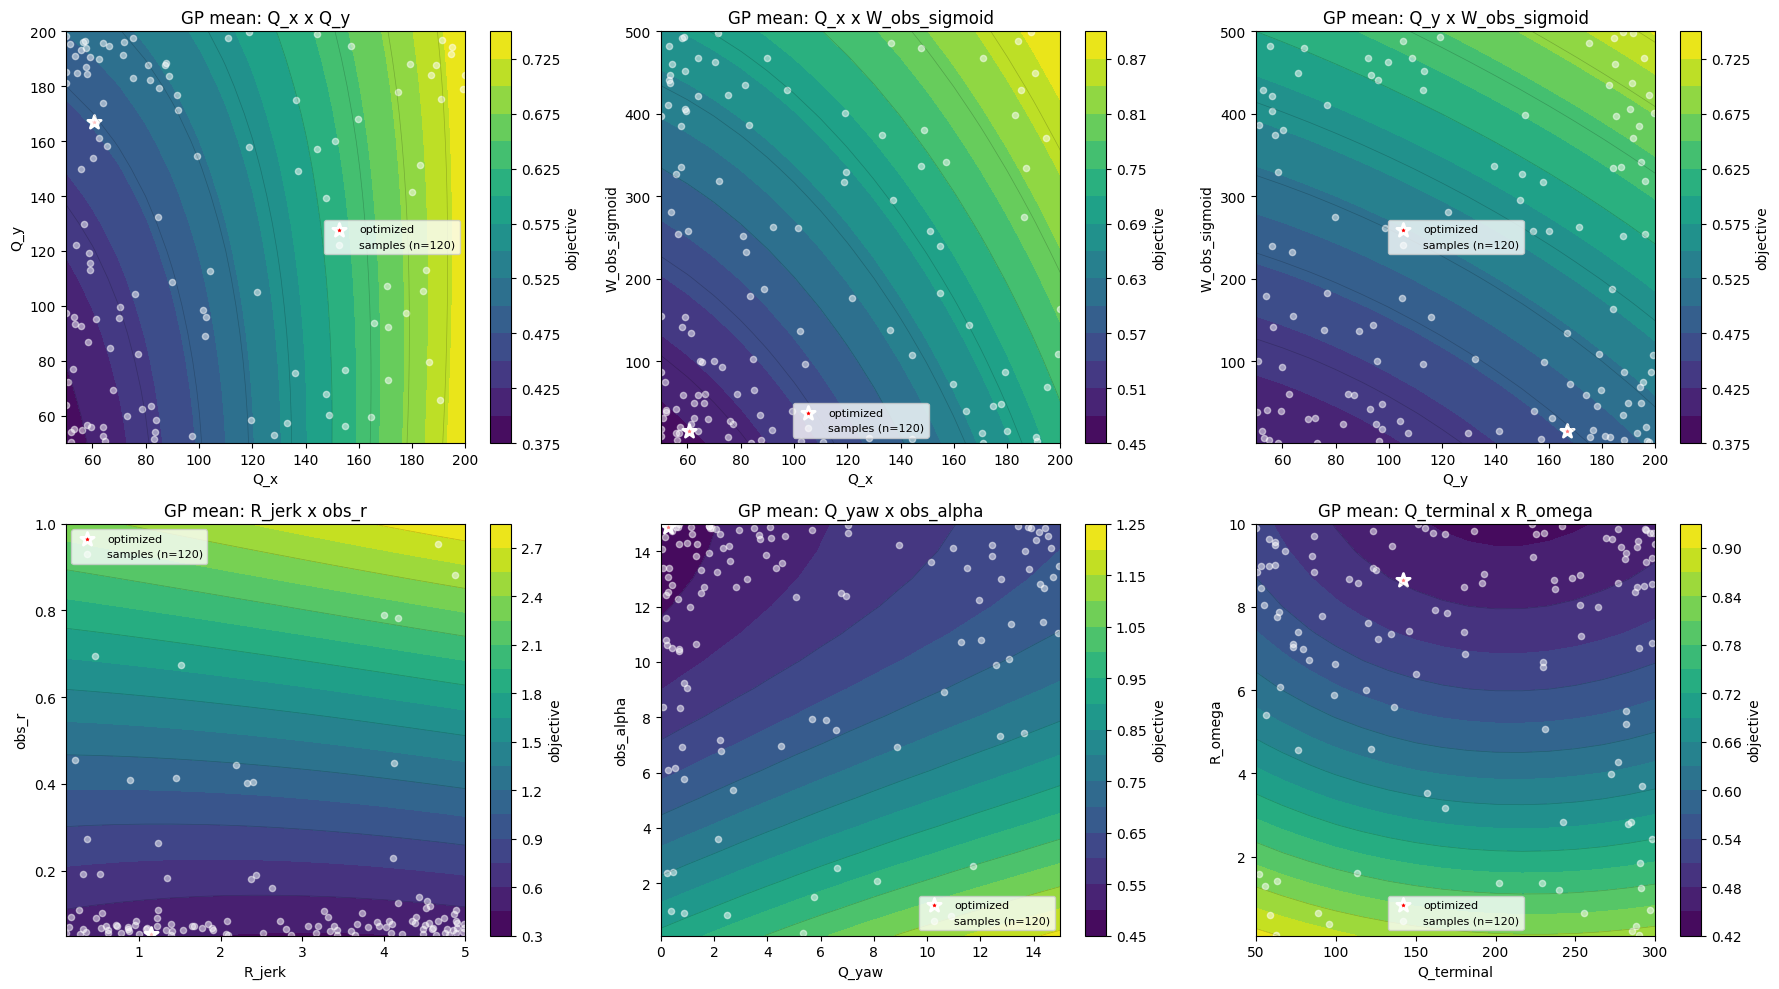

[GP-TUNE] GP surrogate 2D sections plotted with uncertainty estimation


In [21]:
log_section('GP Surrogate Model Visualization')

# Fit final GP on all data
X_arr = np.asarray(X, dtype=np.float64)
y_arr = np.asarray(y, dtype=np.float64)
Xn = scaler.transform(X_arr)
gp_final = fit_gp(Xn, y_arr)

log_step('Fitted GP surrogate on all collected samples')

# 2D slices with uncertainty bands
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

param_pairs = [
    ('Q_x', 'Q_y'),
    ('Q_x', 'W_obs_sigmoid'),
    ('Q_y', 'W_obs_sigmoid'),
    ('R_jerk', 'obs_r'),
    ('Q_yaw', 'obs_alpha'),
    ('Q_terminal', 'R_omega'),
]

for idx, (p1, p2) in enumerate(param_pairs):
    ax = axes[idx]
    i1, i2 = PARAM_NAMES.index(p1), PARAM_NAMES.index(p2)
    
    x1 = np.linspace(*PARAM_BOUNDS[p1], 16)
    x2 = np.linspace(*PARAM_BOUNDS[p2], 16)
    X1, X2 = np.meshgrid(x1, x2)
    Z_mu = np.zeros_like(X1)
    Z_std = np.zeros_like(X1)
    
    for i, a in enumerate(x1):
        for j, b in enumerate(x2):
            xprobe = best_x.copy()
            xprobe[i1] = a
            xprobe[i2] = b
            xprobe_n = scaler.transform(xprobe.reshape(1, -1))
            mu, std = gp_final.predict(xprobe_n, return_std=True)
            Z_mu[j, i] = mu[0]
            Z_std[j, i] = std[0]
    
    # Plot mean with uncertainty bands
    im = ax.contourf(X1, X2, Z_mu, levels=15, cmap='viridis')
    ax.contour(X1, X2, Z_mu, levels=8, colors='k', alpha=0.2, linewidths=0.5)
    
    # Mark best point
    ax.scatter([best_x[i1]], [best_x[i2]], c='r', s=100, marker='*', edgecolors='white', linewidths=2, label='optimized')
    
    # Mark collected samples
    samples_p1 = X_arr[:, i1]
    samples_p2 = X_arr[:, i2]
    ax.scatter(samples_p1, samples_p2, c='white', s=20, alpha=0.5, label=f'samples (n={len(X_arr)})')
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'GP mean: {p1} x {p2}')
    ax.legend(fontsize=8, loc='best')
    fig.colorbar(im, ax=ax, label='objective')

plt.tight_layout()
plt.show()

log_step('GP surrogate 2D sections plotted with uncertainty estimation')


GP posterior marginals per parameter (with log-scale, jitter, and saving)
[GP-TUNE] Using 120 observed samples for overlay


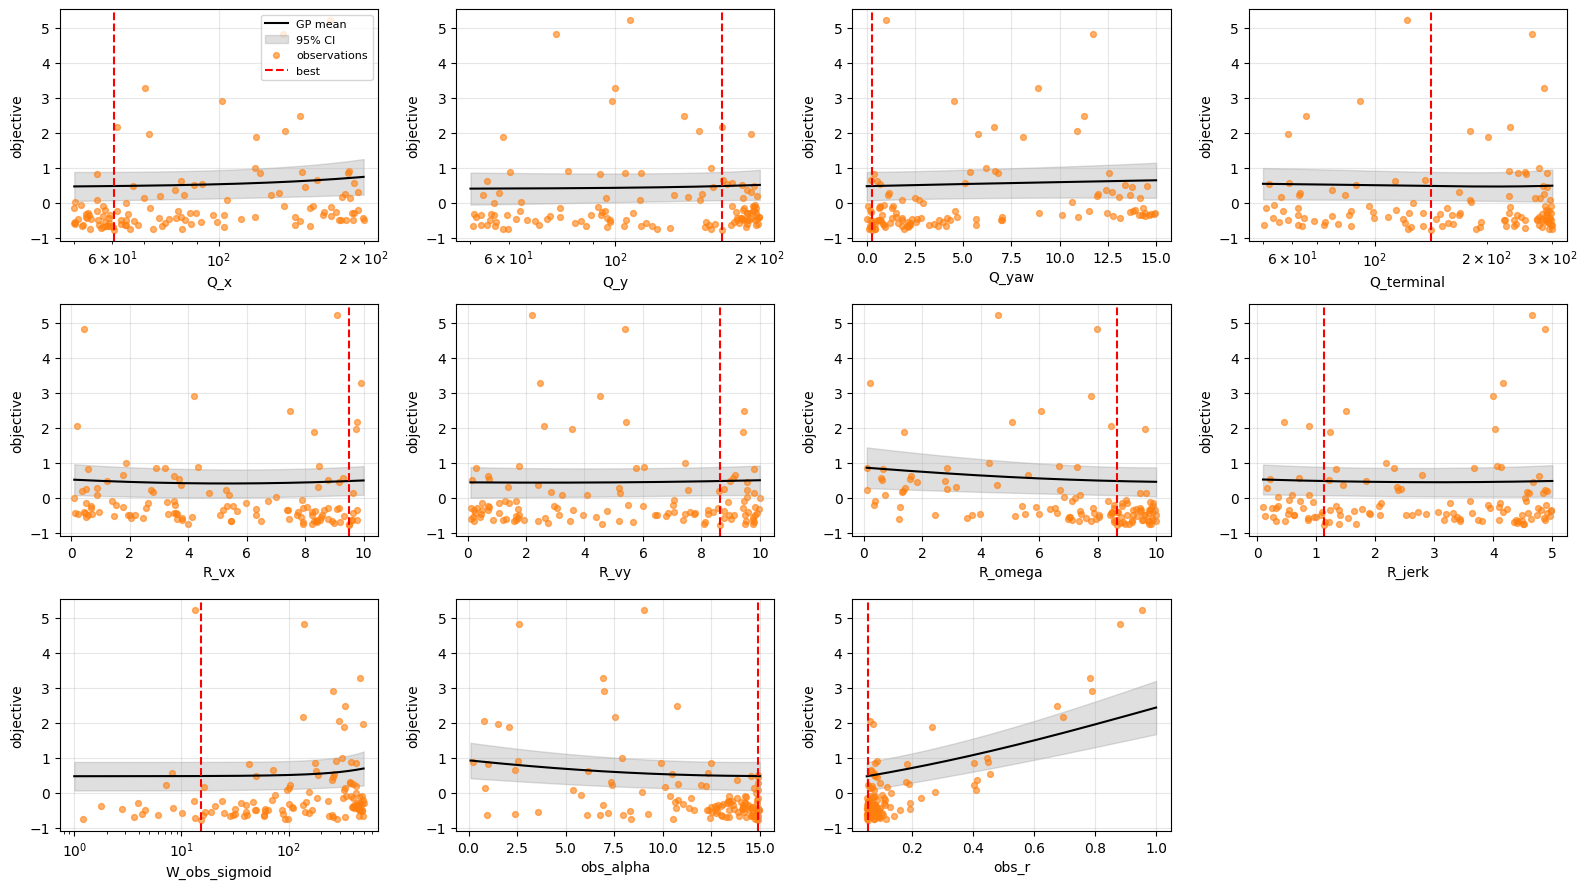

[GP-TUNE] Plotted GP posterior marginals and saved figures to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_marginals/gp_marginals_combined.png


In [28]:
log_section('GP posterior marginals per parameter (with log-scale, jitter, and saving)')

# Ensure X_arr exists
if 'X_arr' not in globals():
    X_arr = np.asarray(X, dtype=np.float64)

# Choose observed samples source robustly
if 'gp_final' in globals() and hasattr(gp_final, 'X_train_') and gp_final.X_train_.shape[0] > 0:
    X_obs = scaler.inverse_transform(np.asarray(gp_final.X_train_))
    y_obs = np.asarray(gp_final.y_train_, dtype=np.float64)
else:
    X_obs = X_arr
    y_obs = np.asarray(y, dtype=np.float64)

log_step(f'Using {X_obs.shape[0]} observed samples for overlay')

# Params to plot on log scale (ranges spanning orders of magnitude)
LOG_PARAMS = {'Q_x', 'Q_y', 'W_obs_sigmoid', 'Q_terminal'}

n_params = len(PARAM_NAMES)
import math
ncols = 4
nrows = math.ceil(n_params / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

# Output directory for saved figures
out_dir = REPO_ROOT / 'bag_gp_tuning' / 'gp_marginals'
out_dir.mkdir(parents=True, exist_ok=True)

np.random.seed(int(RANDOM_SEED))

for i, pname in enumerate(PARAM_NAMES):
    ax = axes[i]
    lo, hi = PARAM_BOUNDS[pname]

    # choose linear or log spacing
    if pname in LOG_PARAMS and lo > 0:
        xs = np.logspace(np.log10(lo), np.log10(hi), 300)
    else:
        xs = np.linspace(lo, hi, 300)

    # Build probes keeping other dims at best_x
    Xprobe = np.tile(best_x.copy(), (len(xs), 1))
    Xprobe[:, i] = xs
    Xprobe_n = scaler.transform(Xprobe)

    mu, std = gp_final.predict(Xprobe_n, return_std=True)
    ax.plot(xs, mu, color='k', lw=1.5, label='GP mean')
    ci_low = mu - 1.96 * std
    ci_high = mu + 1.96 * std
    ax.fill_between(xs, ci_low, ci_high, color='gray', alpha=0.25, label='95% CI')

    # Scatter observed samples projected onto this axis with small y-jitter
    obs_x = X_obs[:, i]
    if y_obs.size > 1:
        jitter_scale = max(1e-6, (np.max(y_obs) - np.min(y_obs)) * 0.02)
    else:
        jitter_scale = 1e-6
    y_jitter = y_obs + np.random.normal(0.0, jitter_scale, size=y_obs.shape)
    ax.scatter(obs_x, y_obs, c='C1', s=18, alpha=0.6, label='observations' if i==0 else '')

    # Mark best
    ax.axvline(best_x[i], color='r', linestyle='--', label='best' if i==0 else '')

    # Axis formatting
    ax.set_xlabel(pname)
    ax.set_ylabel('objective')
    ax.grid(True, alpha=0.3)
    if pname in LOG_PARAMS and lo > 0:
        ax.set_xscale('log')

    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

    # Also save single-parameter figure
    fig_i, ax_i = plt.subplots(1, 1, figsize=(6, 4))
    ax_i.plot(xs, mu, color='k', lw=1.5, label='GP mean')
    ax_i.fill_between(xs, ci_low, ci_high, color='gray', alpha=0.25, label='95% CI')
    ax_i.scatter(obs_x, y_jitter, c='C1', s=18, alpha=0.6)
    ax_i.axvline(best_x[i], color='r', linestyle='--')
    if pname in LOG_PARAMS and lo > 0:
        ax_i.set_xscale('log')
    ax_i.set_xlabel(pname)
    ax_i.set_ylabel('objective')
    ax_i.grid(True, alpha=0.3)
    fig_i.tight_layout()
    fig_i.savefig(out_dir / f'{pname}_marginal.png', dpi=200)
    plt.close(fig_i)

# Turn off unused axes
for j in range(n_params, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# Save combined figure
combined_path = out_dir / 'gp_marginals_combined.png'
fig.savefig(combined_path, dpi=200)
plt.show()

log_step(f'Plotted GP posterior marginals and saved figures to: {combined_path}')

In [23]:
log_section('Extract and compare baseline vs optimized MPC trajectories')

def extract_mpc_trajectories(frames, baseline_cfg, optimized_cfg, n_frames=20):
    """Run MPC with baseline and optimized configs and return trajectory comparisons."""
    baseline_tracker = MPCTracker(config=baseline_cfg)
    optimized_tracker = MPCTracker(config=optimized_cfg)
    
    comparisons = []
    frame_indices = np.linspace(0, len(frames) - 1, min(n_frames, len(frames))).astype(int)
    
    log_step(f'Extracting MPC trajectories for {len(frame_indices)} frames')
    
    for frame_idx in frame_indices:
        fr = frames[frame_idx]
        state = fr['state']
        path = fr['path']
        obs = fr['obs_xy']
        
        # Baseline
        res_base = baseline_tracker.solve(state, path, obstacle_points_2d=obs)
        traj_base = res_base.x_pred[:, :2] if res_base.success and res_base.x_pred is not None else None
        
        # Optimized
        res_opt = optimized_tracker.solve(state, path, obstacle_points_2d=obs)
        traj_opt = res_opt.x_pred[:, :2] if res_opt.success and res_opt.x_pred is not None else None
        
        comparisons.append({
            'frame_idx': int(frame_idx),
            'state': state.copy(),
            'path': np.asarray(path)[:, :2],
            'obs_xy': obs.copy() if obs is not None and len(obs) > 0 else np.empty((0, 2)),
            'traj_baseline': traj_base,
            'traj_optimized': traj_opt,
            'success_baseline': res_base.success,
            'success_optimized': res_opt.success,
        })
    
    log_step(f'Extracted {len(comparisons)} trajectory comparisons')
    return comparisons

# Generate trajectories
baseline_cfg_final = base_cfg  # unchanged
optimized_cfg_final = make_cfg_from_vec(base_cfg, best_x)

traj_comps = extract_mpc_trajectories(frames, baseline_cfg_final, optimized_cfg_final, n_frames=20)


Extract and compare baseline vs optimized MPC trajectories
[GP-TUNE] Extracting MPC trajectories for 20 frames
[GP-TUNE] Extracted 20 trajectory comparisons


In [24]:
log_section('Load Gazebo world file and extract environment map')

def extract_obstacles_from_sdf(sdf_path):
    """Parse Gazebo world file and extract obstacle positions and sizes."""
    try:
        import xml.etree.ElementTree as ET
    except ImportError:
        log_step('XML parsing not available, skipping world file parsing')
        return None
    
    if not sdf_path.exists():
        log_step(f'World file not found: {sdf_path}')
        return None
    
    try:
        tree = ET.parse(str(sdf_path))
        root = tree.getroot()
        
        obstacles = []
        # Look for models with collision/visual elements
        for model in root.findall('.//model'):
            model_name = model.get('name', 'unknown')
            for link in model.findall('.//link'):
                for collision in link.findall('.//collision'):
                    geom = collision.find('.//geometry')
                    if geom is None:
                        continue
                    
                    # Extract position
                    pose_elem = collision.find('./pose')
                    if pose_elem is None:
                        pose_elem = model.find('./pose')
                    
                    if pose_elem is not None and pose_elem.text:
                        parts = pose_elem.text.strip().split()
                        if len(parts) >= 2:
                            x, y = float(parts[0]), float(parts[1])
                        else:
                            continue
                    else:
                        continue
                    
                    # Extract shape (box, cylinder, sphere)
                    box = geom.find('./box')
                    cylinder = geom.find('./cylinder')
                    sphere = geom.find('./sphere')
                    
                    if box is not None:
                        size = box.find('./size')
                        if size is not None and size.text:
                            dims = [float(d) for d in size.text.strip().split()]
                            r = max(dims[:2]) / 2.0
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'box'})
                    elif cylinder is not None:
                        radius = cylinder.find('./radius')
                        if radius is not None and radius.text:
                            r = float(radius.text.strip())
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'cylinder'})
                    elif sphere is not None:
                        radius = sphere.find('./radius')
                        if radius is not None and radius.text:
                            r = float(radius.text.strip())
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'sphere'})
        
        log_step(f'Extracted {len(obstacles)} obstacles from {sdf_path.name}')
        return obstacles
    except Exception as e:
        log_step(f'Error parsing world file: {e}')
        return None

# Try to load close_office world
worlds_dir = REPO_ROOT / 'src' / 'sim_worlds' / 'worlds'
world_file = worlds_dir / 'close_office.world'

world_obstacles = None
if world_file.exists():
    world_obstacles = extract_obstacles_from_sdf(world_file)
else:
    log_step(f'World file not found: {world_file}')
    log_step('Will plot trajectories without background map')


Load Gazebo world file and extract environment map
[GP-TUNE] World file not found: /media/lorenzo/writable/Go2_navigation/src/sim_worlds/worlds/close_office.world
[GP-TUNE] Will plot trajectories without background map



Baseline vs Optimized Trajectory Overlay


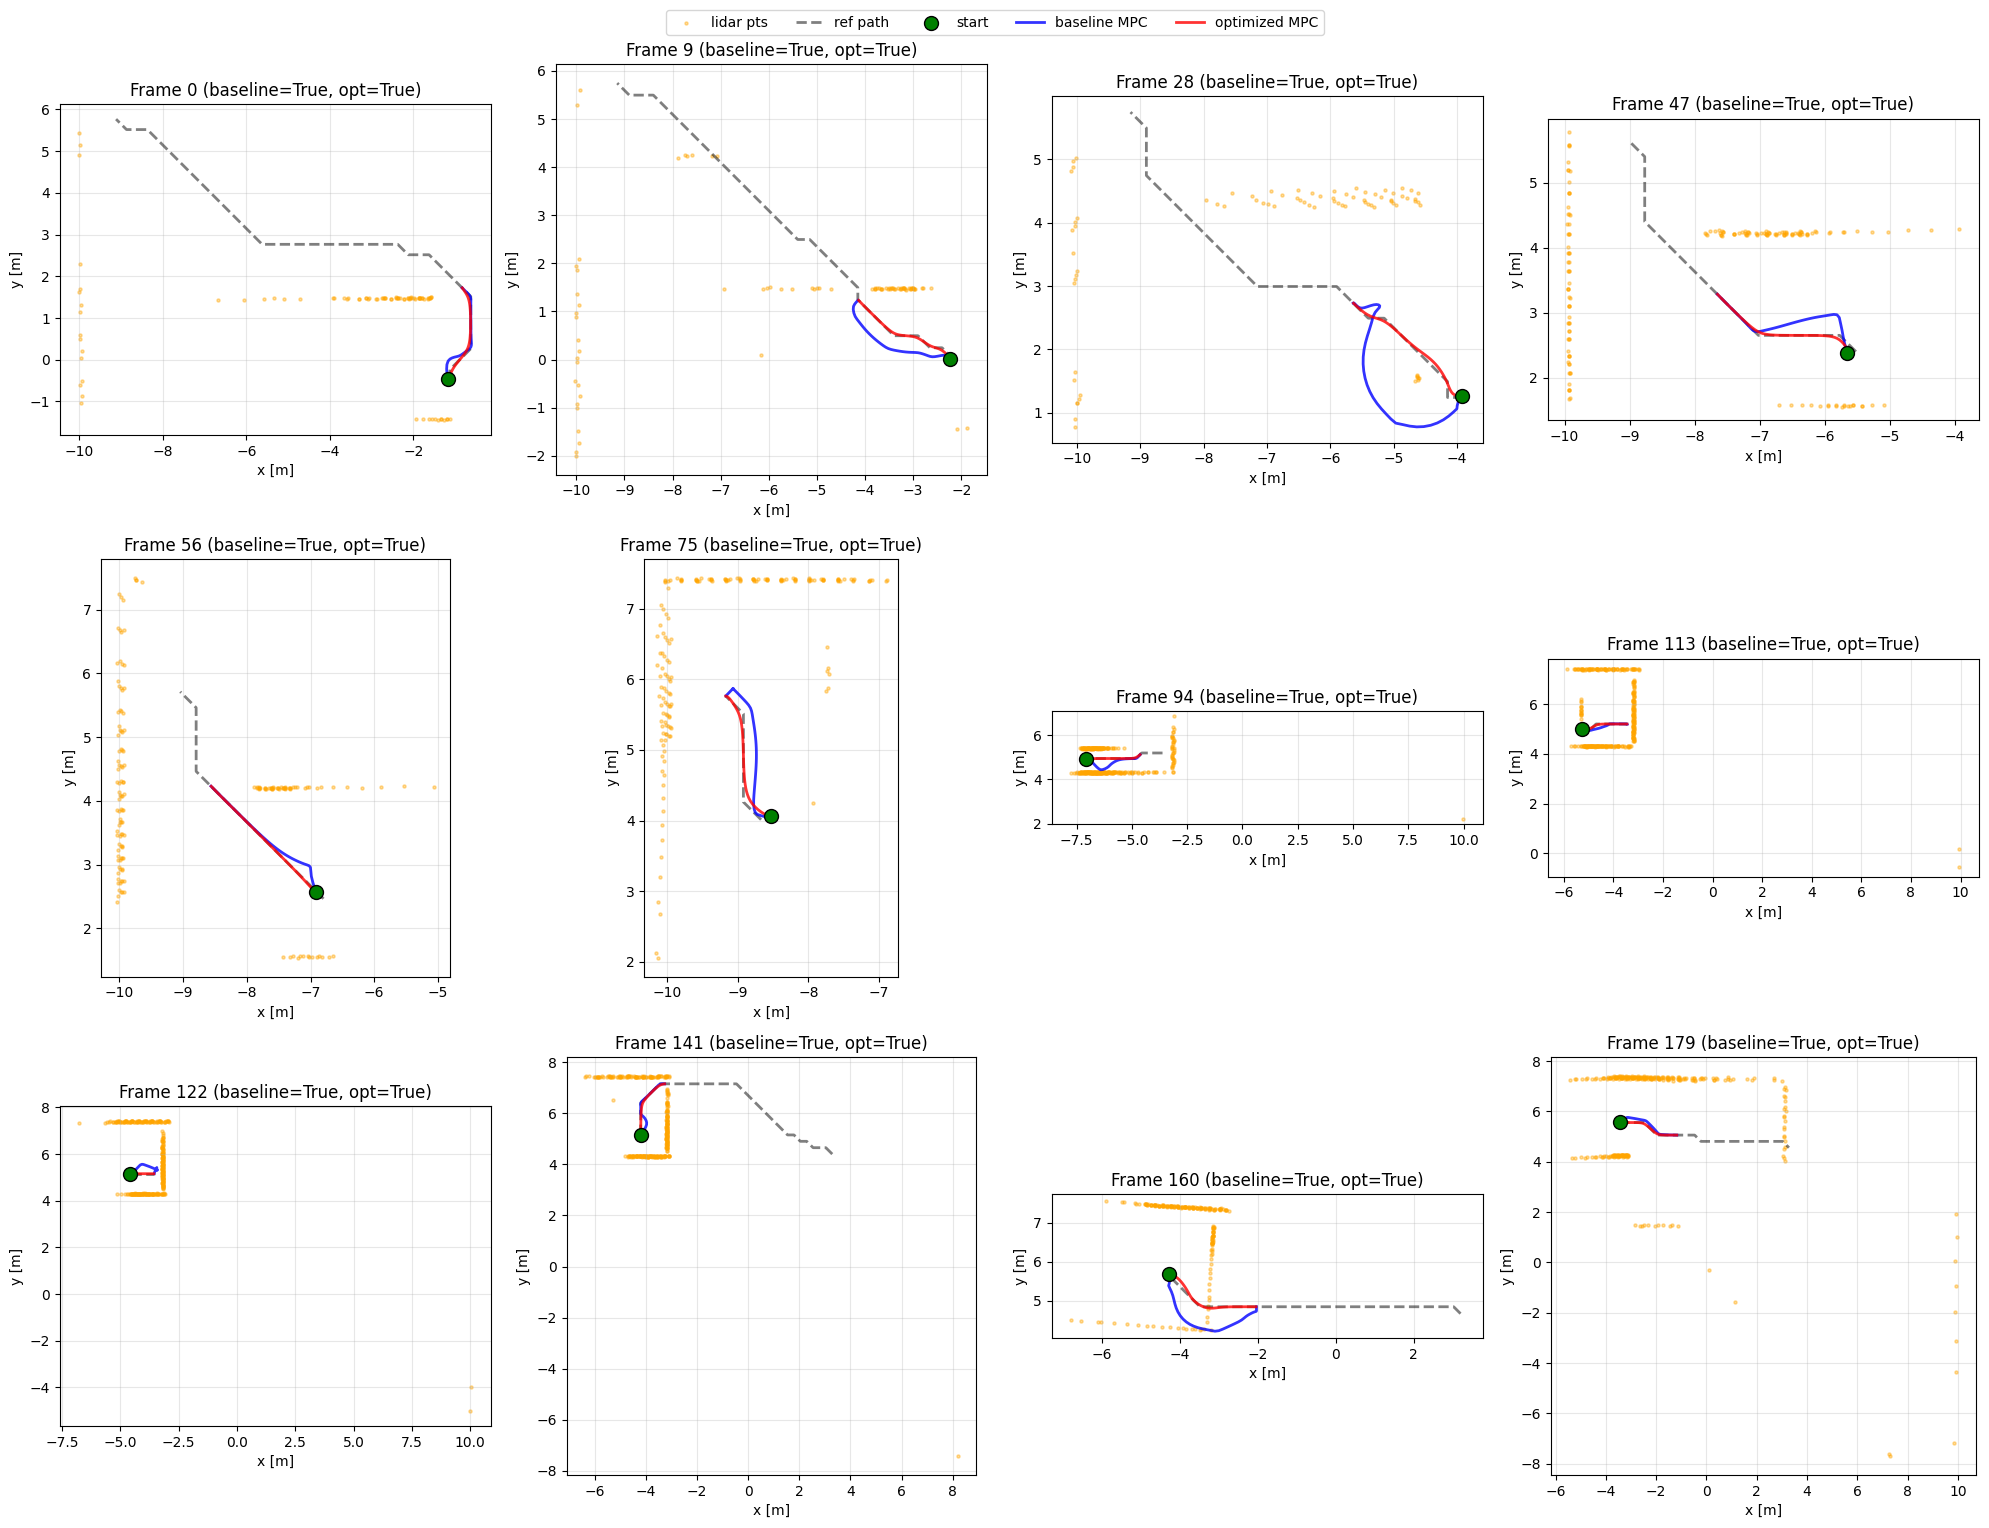

[GP-TUNE] Trajectory comparisons plotted with environment obstacles


In [25]:
log_section('Baseline vs Optimized Trajectory Overlay')

# Select a few representative trajectories for detailed plotting
n_to_plot = min(12, len(traj_comps))
plot_indices = np.linspace(0, len(traj_comps) - 1, n_to_plot).astype(int)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for plot_idx, comp_idx in enumerate(plot_indices):
    ax = axes[plot_idx]
    comp = traj_comps[comp_idx]
    
    # Plot obstacles if available
    if world_obstacles is not None:
        for obs in world_obstacles:
            circle = plt.Circle((obs['x'], obs['y']), obs['r'], color='gray', alpha=0.3, label='obstacles' if plot_idx == 0 else '')
            ax.add_patch(circle)
    
    # Plot lidar points from bag
    if comp['obs_xy'] is not None and len(comp['obs_xy']) > 0:
        ax.scatter(comp['obs_xy'][:, 0], comp['obs_xy'][:, 1], c='orange', s=5, alpha=0.4, label='lidar pts' if plot_idx == 0 else '')
    
    # Plot reference path
    path = comp['path']
    if path is not None and len(path) > 0:
        ax.plot(path[:, 0], path[:, 1], 'k--', lw=2, alpha=0.5, label='ref path' if plot_idx == 0 else '')
    
    # Plot robot starting state
    state = comp['state']
    ax.scatter([state[0]], [state[1]], c='green', s=100, marker='o', edgecolors='black', linewidths=1, label='start' if plot_idx == 0 else '', zorder=10)
    
    # Plot MPC trajectories
    if comp['traj_baseline'] is not None:
        ax.plot(comp['traj_baseline'][:, 0], comp['traj_baseline'][:, 1], 'b-', lw=2, alpha=0.8, label='baseline MPC' if plot_idx == 0 else '')
    
    if comp['traj_optimized'] is not None:
        ax.plot(comp['traj_optimized'][:, 0], comp['traj_optimized'][:, 1], 'r-', lw=2, alpha=0.8, label='optimized MPC' if plot_idx == 0 else '')
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Frame {comp["frame_idx"]} (baseline={comp["success_baseline"]}, opt={comp["success_optimized"]})')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')

# Add legend to first plot
if axes[0].get_legend() is None:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5, fontsize=10)

plt.tight_layout()
plt.show()

log_step('Trajectory comparisons plotted with environment obstacles')


Trajectory statistics and aggregate comparison
[GP-TUNE] Trajectory statistics:
[GP-TUNE]   Baseline success rate: 100.0%
[GP-TUNE]   Optimized success rate: 100.0%
[GP-TUNE]   Baseline mean path length: 2.733 m
[GP-TUNE]   Optimized mean path length: 2.289 m


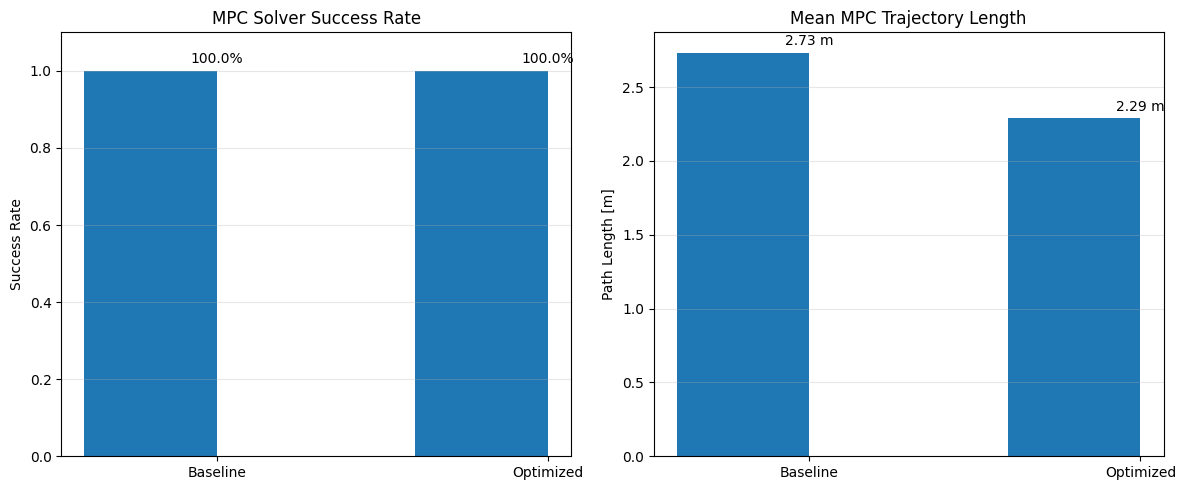

[GP-TUNE] Trajectory comparison plots complete


In [26]:
log_section('Trajectory statistics and aggregate comparison')

# Compute trajectory statistics
stats = {'baseline_success': 0, 'optimized_success': 0, 'baseline_dist': [], 'optimized_dist': []}

for comp in traj_comps:
    if comp['success_baseline']:
        stats['baseline_success'] += 1
        if comp['traj_baseline'] is not None:
            dist = np.sum(np.linalg.norm(np.diff(comp['traj_baseline'], axis=0), axis=1))
            stats['baseline_dist'].append(dist)
    
    if comp['success_optimized']:
        stats['optimized_success'] += 1
        if comp['traj_optimized'] is not None:
            dist = np.sum(np.linalg.norm(np.diff(comp['traj_optimized'], axis=0), axis=1))
            stats['optimized_dist'].append(dist)

stats['baseline_success_rate'] = stats['baseline_success'] / len(traj_comps)
stats['optimized_success_rate'] = stats['optimized_success'] / len(traj_comps)
stats['baseline_mean_dist'] = np.mean(stats['baseline_dist']) if stats['baseline_dist'] else 0.0
stats['optimized_mean_dist'] = np.mean(stats['optimized_dist']) if stats['optimized_dist'] else 0.0

log_step('Trajectory statistics:')
log_step(f'  Baseline success rate: {stats["baseline_success_rate"]:.1%}')
log_step(f'  Optimized success rate: {stats["optimized_success_rate"]:.1%}')
log_step(f'  Baseline mean path length: {stats["baseline_mean_dist"]:.3f} m')
log_step(f'  Optimized mean path length: {stats["optimized_mean_dist"]:.3f} m')

# Comparison bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Success rates
ax = axes[0]
x = np.array([0, 1])
y = np.array([stats['baseline_success_rate'], stats['optimized_success_rate']])
ax.bar(x - 0.2, y, width=0.4, label='success rate')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Optimized'])
ax.set_ylabel('Success Rate')
ax.set_title('MPC Solver Success Rate')
ax.set_ylim([0, 1.1])
for i, v in enumerate(y):
    ax.text(x[i], v + 0.02, f'{v:.1%}', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Mean path length
ax = axes[1]
y_dist = np.array([stats['baseline_mean_dist'], stats['optimized_mean_dist']])
ax.bar(x - 0.2, y_dist, width=0.4, label='mean path length')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Optimized'])
ax.set_ylabel('Path Length [m]')
ax.set_title('Mean MPC Trajectory Length')
for i, v in enumerate(y_dist):
    ax.text(x[i], v + 0.05, f'{v:.2f} m', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

log_step('Trajectory comparison plots complete')

In [27]:
# Plot the predicted mean and uncertainty for the best parameter set
best_x_n = scaler.transform(best_x.reshape(1, -1))
best_mu, best_std = gp_final.predict(best_x_n, return_std=True)
log_step(f'Best parameter set prediction: mean={best_mu[0]:.4f}, std={best_std[0]:.4f}')    



[GP-TUNE] Best parameter set prediction: mean=0.4773, std=0.2063
